# Identification of velocity/pressure field patterns in jet flows 

Alejandro Fonseca

In [1]:
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import os
from scipy.signal import get_window
from numpy.fft import rfft
import matplotlib.animation as animation
from IPython.display import HTML, display

## Loading Data

In [7]:
# === CONFIG ===
mat_path = 'data/Run1_PIV.mat'

# === LOAD MAT FILE ===
with h5py.File(mat_path, 'r') as f:
    print("Top-level keys:", list(f.keys()))

    print("\nField sizes:")
    for key in f.keys():
        try:
            data = f[key]
            print(f"{key}: shape = {data.shape}, dtype = {data.dtype}")
        except Exception as e:
            print(f"{key}: could not access {e}")

Top-level keys: ['Phi', 'Psi', 'Res', 'Sig', 'U', 'Uc', 'Um', 'Uph', 'V', 'Vm', 'Vph', 'X', 'Y', 'tke', 'u', 'u2', 'uv', 'v', 'v2']

Field sizes:
Phi: shape = (2031, 171622), dtype = float64
Psi: shape = (2031, 2031), dtype = float64
Res: shape = (1, 1), dtype = float64
Sig: shape = (1, 2031), dtype = float64
U: shape = (2031, 269, 319), dtype = float64
Uc: shape = (1, 1), dtype = float64
Um: shape = (269, 319), dtype = float64
Uph: shape = (20, 269, 319), dtype = float64
V: shape = (2031, 269, 319), dtype = float64
Vm: shape = (269, 319), dtype = float64
Vph: shape = (20, 269, 319), dtype = float64
X: shape = (269, 319), dtype = float32
Y: shape = (269, 319), dtype = float32
tke: shape = (269, 319), dtype = float64
u: shape = (2031, 269, 319), dtype = float64
u2: shape = (269, 319), dtype = float64
uv: shape = (269, 319), dtype = float64
v: shape = (2031, 269, 319), dtype = float64
v2: shape = (269, 319), dtype = float64


In [4]:
def load_piv_data(mat_path):
    """Load PIV data from .mat file"""
    data = {}
    with h5py.File(mat_path, 'r') as f:
        # Load key variables
        data['Phi'] = f['Phi'][:] # POD spatial modes (2031 modes × 171622 flattened spatial points(269x319x2components))
        data['Psi'] = f['Psi'][:] # POD temporal coefficients (2031 snapshots × 2031 modes)
        data['Res'] = f['Res'][0,0] # resolution (jet diameter D)
        data['Sig'] = f['Sig'][:] # POD singular values/eigenvalues (energy of each mode) (1x2031)
        data['U'] = f['U'][:]  # instantaneous horizontal velocity component (2031 snapshots × 269×319 grid)
        data['Uc'] = f['Uc'][0,0] # characteristic velocity for non-dimensionalizing (scalar)
        data['Um'] = f['Um'][:]  # time-averaged horizontal velocity component (269x319)
        data['Uph'] = f['Uph'][:] # phase-averaged horizontal velocity component (20 phases × spatial grid)
        data['V'] = f['V'][:]  # instantaneous vertical velocity component (2031 snapshots × 269×319 grid)
        data['Vm'] = f['Vm'][:] # time-averaged vertical velocity component (269x319)
        data['Vph'] = f['Vph'][:] # phase-averaged vertical velocity component (20 phases × spatial grid)
        data['X'] = f['X'][:] # spatial coordinate meshgrid (269x319) (non-dimensional X=x/D)
        data['Y'] = f['Y'][:] # spatial coordinate meshgrid (269x319) (non-dimensional Y=y/D)
        data['tke'] = f['tke'][:] # turbulent kinetic energy (269x319)
        data['u'] = f['u'][:] # fluctuating horizontal velocity component, u = U-Um (2031 snapshots × 269×319 grid)
        data['u2'] = f['u2'][:] # reynolds normal horizontal stress <uu> (269x319)
        data['uv'] = f['uv'][:] # reynolds shear stress <uv> (269x319)
        data['v'] = f['v'][:] # fluctuating vertical velocity component, v = V-Vm (2031 snapshots × 269×319 grid)
        data['v2'] = f['v2'][:] # reynolds normal vertical stress <vv> (269x319)
        
    
    return data

In [ ]:

data = load_piv_data(mat_path)

# Data Analysis and Visualization

## Data Cleaning

In [9]:
def assess_data_quality(data):
    print("=== DATA QUALITY ASSESSMENT ===")
    
    for key, value in data.items():
        print(f"\n{key}:")
        print(f"  Shape: {value.shape}")
        print(f"  Data type: {value.dtype}")
        print(f"  Memory usage: {value.nbytes / 1e6:.1f} MB")
        
        # Check for problematic values
        if np.issubdtype(value.dtype, np.number):
            n_nan = np.sum(np.isnan(value))
            n_inf = np.sum(np.isinf(value))
            n_zero = np.sum(value == 0)
            
            print(f"  NaN values: {n_nan} ({n_nan/value.size*100:.2f}%)")
            print(f"  Inf values: {n_inf} ({n_inf/value.size*100:.2f}%)")
            print(f"  Zero values: {n_zero} ({n_zero/value.size*100:.2f}%)")
            print(f"  Range: [{np.nanmin(value):.3f}, {np.nanmax(value):.3f}]")
            print(f"  Mean: {np.nanmean(value):.3f}, Std: {np.nanstd(value):.3f}")


assess_data_quality(data)

=== DATA QUALITY ASSESSMENT ===

Phi:
  Shape: (2031, 171622)
  Data type: float64
  Memory usage: 2788.5 MB
  NaN values: 0 (0.00%)
  Inf values: 0 (0.00%)
  Zero values: 0 (0.00%)
  Range: [-0.101, 0.127]
  Mean: 0.000, Std: 0.002

Psi:
  Shape: (2031, 2031)
  Data type: float64
  Memory usage: 33.0 MB
  NaN values: 0 (0.00%)
  Inf values: 0 (0.00%)
  Zero values: 0 (0.00%)
  Range: [-0.177, 0.122]
  Mean: 0.000, Std: 0.022

Res:
  Shape: ()
  Data type: float64
  Memory usage: 0.0 MB
  NaN values: 0 (0.00%)
  Inf values: 0 (0.00%)
  Zero values: 0 (0.00%)
  Range: [22.700, 22.700]
  Mean: 22.700, Std: 0.000

Sig:
  Shape: (1, 2031)
  Data type: float64
  Memory usage: 0.0 MB
  NaN values: 0 (0.00%)
  Inf values: 0 (0.00%)
  Zero values: 0 (0.00%)
  Range: [0.000, 131.517]
  Mean: 6.213, Std: 11.617

U:
  Shape: (2031, 269, 319)
  Data type: float64
  Memory usage: 1394.3 MB
  NaN values: 0 (0.00%)
  Inf values: 0 (0.00%)
  Zero values: 0 (0.00%)
  Range: [-0.495, 1.377]
  Mean: 0.09

In [10]:
def check_spatial_consistency(data):
    print("=== SPATIAL CONSISTENCY CHECKS ===")
    
    X, Y = data['X'], data['Y']
    
    # Check grid regularity
    dx = np.diff(X[:, 0])
    dy = np.diff(Y[0, :])
    
    print(f"Grid spacing X: min={dx.min():.6f}, max={dx.max():.6f}, std={dx.std():.6f}")
    print(f"Grid spacing Y: min={dy.min():.6f}, max={dy.max():.6f}, std={dy.std():.6f}")
    
    if dx.std() > 1e-6 or dy.std() > 1e-6:
        print("WARNING: Non-uniform grid detected!")
    
    # Check for spatial discontinuities in velocity
    for key in ['U', 'V']:
        if key in data and len(data[key].shape) > 2:
            # Check a few time steps
            for t in [0, len(data[key])//2, -1]:
                field = data[key][t]
                grad_x = np.gradient(field, axis=1)
                grad_y = np.gradient(field, axis=0)
                
                # Look for extreme gradients
                extreme_grad = np.percentile(np.abs(grad_x), 99.9)
                print(f"{key}[t={t}]: 99.9th percentile gradient = {extreme_grad:.3f}")

check_spatial_consistency(data)

=== SPATIAL CONSISTENCY CHECKS ===
Grid spacing X: min=0.035241, max=0.035243, std=0.000000
Grid spacing Y: min=0.035242, max=0.035243, std=0.000000
U[t=0]: 99.9th percentile gradient = 0.163
U[t=1015]: 99.9th percentile gradient = 0.240
U[t=-1]: 99.9th percentile gradient = 0.168
V[t=0]: 99.9th percentile gradient = 0.039
V[t=1015]: 99.9th percentile gradient = 0.041
V[t=-1]: 99.9th percentile gradient = 0.033


In [11]:
def check_temporal_consistency(data):
    print("=== TEMPORAL CONSISTENCY CHECKS ===")
    
    nt = data['U'].shape[0]
    
    # Check for sudden jumps in time series
    center_point = (data['U'].shape[1]//2, data['U'].shape[2]//2)
    u_center = data['U'][:, center_point[0], center_point[1]]
    v_center = data['V'][:, center_point[0], center_point[1]]
    
    # Temporal derivatives
    du_dt = np.diff(u_center)
    dv_dt = np.diff(v_center)
    
    print(f"Temporal derivatives - U: max={np.max(np.abs(du_dt)):.3f}")
    print(f"Temporal derivatives - V: max={np.max(np.abs(dv_dt)):.3f}")
    
    # Check for identical consecutive frames
    identical_frames = 0
    for t in range(1, nt):
        if np.allclose(data['U'][t], data['U'][t-1], rtol=1e-10):
            identical_frames += 1
    
    print(f"Identical consecutive frames: {identical_frames}")

check_temporal_consistency(data)

=== TEMPORAL CONSISTENCY CHECKS ===
Temporal derivatives - U: max=0.340
Temporal derivatives - V: max=0.229
Identical consecutive frames: 0


## Jet Characteristics Analysis

In [12]:
# === JET FLOW ANALYSIS ===
def analyze_jet_characteristics(data):
    """Analyze key jet flow characteristics"""
    print("=== JET FLOW CHARACTERISTICS (Non-dimensional) ===")
    
    X, Y = data['X'], data['Y']
    Um, Vm = data['Um'], data['Vm']
    
    # Domain extents
    x_min, x_max = X.min(), X.max()
    y_min, y_max = Y.min(), Y.max()
    dx = X[1,0] - X[0,0]
    dy = Y[0,1] - Y[0,0]
    
    print(f"Domain: x/D ∈ [{x_min:.1f}, {x_max:.1f}], y/D ∈ [{y_min:.1f}, {y_max:.1f}]")
    print(f"Grid resolution: dx/D = {dx:.3f}, dy/D = {dy:.3f}")
    print(f"Grid size: {X.shape[1]} x {X.shape[0]} points")
    print(f"Time snapshots: {data['U'].shape[0]}")
    print(f"Phase-averaged bins: {data['Uph'].shape[0]}")
    
    # Jet characteristics
    U_mag = np.sqrt(Um**2 + Vm**2)
    
    # Find jet centerline (y=0 or maximum velocity line)
    centerline_idx = np.abs(Y[0, :]).argmin()  # Find y≈0
    centerline_U = Um[:, centerline_idx]
    centerline_x = X[:, centerline_idx]
    
    print(f"\n=== CENTERLINE ANALYSIS ===")
    print(f"Centerline at y/D = {Y[0, centerline_idx]:.2f}")
    print(f"Velocity at x/D=1: U/U_inf = {centerline_U[centerline_x>=1][0]:.3f}")
    print(f"Velocity at x/D=4: U/U_inf = {centerline_U[centerline_x>=4][0]:.3f}")
    print(f"Velocity at x/D=8: U/U_inf = {centerline_U[centerline_x>=8][0]:.3f}")
    
    # Jet spreading analysis
    print(f"\n=== JET SPREADING ===")
    for x_loc in [2, 5, x_max]:
        x_idx = np.abs(centerline_x - x_loc).argmin()
        velocity_profile = U_mag[x_idx, :]
        
        # Find jet half-width (where U = 0.5 * U_centerline)
        u_center = velocity_profile[centerline_idx]
        half_velocity = 0.5 * u_center
        
        # Find indices where velocity crosses half-velocity threshold
        above_half = velocity_profile > half_velocity
        if np.any(above_half):
            y_indices = np.where(above_half)[0]
            jet_width = (y_indices[-1] - y_indices[0]) * dy
            print(f"  x/D = {x_loc:.2f}: Half-width = {jet_width/2:.2f}D")
    
    # Turbulence characteristics
    print(f"\n=== TURBULENCE STATISTICS ===")
    tke_max = np.max(data['tke'])
    tke_mean = np.mean(data['tke'][data['tke'] > 0.01*tke_max])  # Exclude low-energy regions
    
    print(f"Peak TKE/U_inf^2: {tke_max:.4f}")
    print(f"Mean TKE/U_inf^2 (active regions): {tke_mean:.4f}")
    
    # Reynolds stress magnitudes
    print(f"Peak uu/U_inf^2: {np.max(data['u2']):.4f}")
    print(f"Peak vv/U_inf^2: {np.max(data['v2']):.4f}")
    print(f"Peak |uv|/U_inf^2: {np.max(np.abs(data['uv'])):.4f}")
    
    return {
        'domain': (x_min, x_max, y_min, y_max),
        'centerline_idx': centerline_idx,
        'resolution': (dx, dy)
    }

info = analyze_jet_characteristics(data)

=== JET FLOW CHARACTERISTICS (Non-dimensional) ===
Domain: x/D ∈ [-0.1, 9.4], y/D ∈ [-5.8, 5.4]
Grid resolution: dx/D = 0.035, dy/D = 0.035
Grid size: 319 x 269 points
Time snapshots: 2031
Phase-averaged bins: 20

=== CENTERLINE ANALYSIS ===
Centerline at y/D = -0.01
Velocity at x/D=1: U/U_inf = 1.027
Velocity at x/D=4: U/U_inf = 0.999
Velocity at x/D=8: U/U_inf = 0.693

=== JET SPREADING ===
  x/D = 2.00: Half-width = 0.53D
  x/D = 5.00: Half-width = 0.53D
  x/D = 9.36: Half-width = 0.70D

=== TURBULENCE STATISTICS ===
Peak TKE/U_inf^2: 0.0331
Mean TKE/U_inf^2 (active regions): 0.0048
Peak uu/U_inf^2: 0.0248
Peak vv/U_inf^2: 0.0426
Peak |uv|/U_inf^2: 0.0072


## Quiver Plot of Mean Velocity

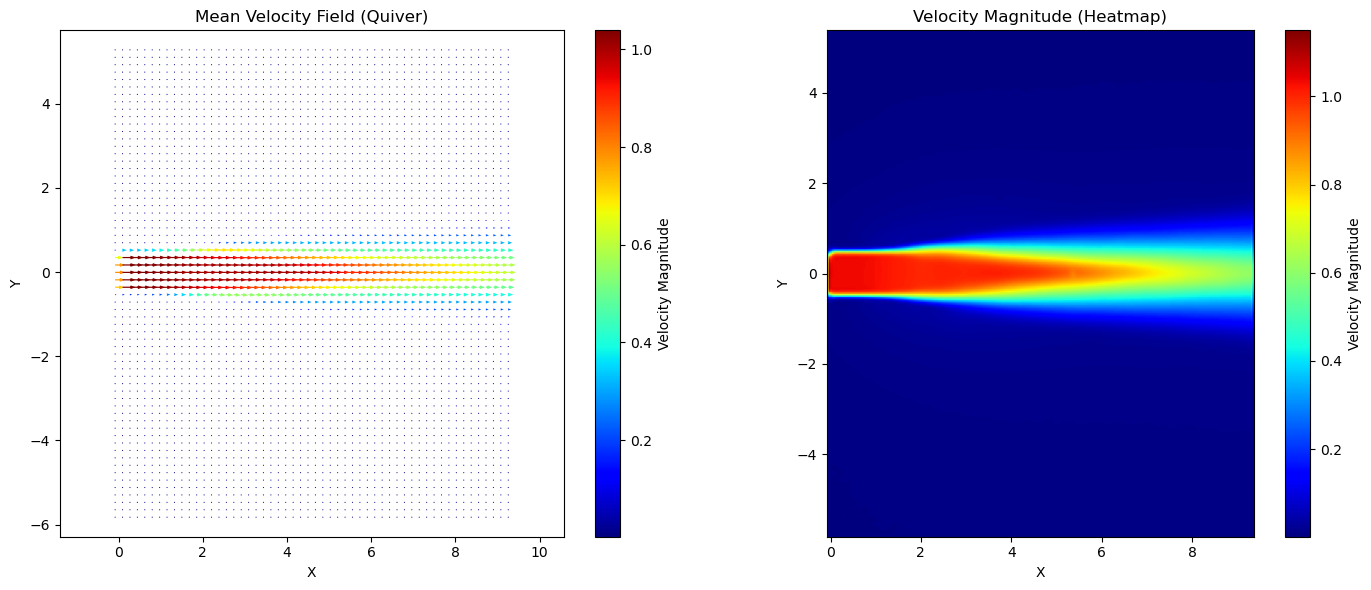

In [13]:
# Subsample for clarity of the quiver plot
step = 5  # Adjust to control density of arrows
Xq = data['X'][::step, ::step]
Yq = data['Y'][::step, ::step]
Uq = data['Um'][::step, ::step]
Vq = data['Vm'][::step, ::step]

# Full-resolution fields for heatmap
X_full = data['X']
Y_full = data['Y']
Um_full = data['Um']
Vm_full = data['Vm']

# Calculate velocity magnitude
speed_q = np.sqrt(Uq**2 + Vq**2) # For quiver
speed_full = np.sqrt(Um_full**2 + Vm_full**2)  # For heatmap

# === Plot side by side ===
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# --- Quiver Plot ---
q = axs[0].quiver(Xq, Yq, Uq, Vq, speed_q, scale=40, cmap='jet', headwidth=3, headlength=4)
axs[0].set_title('Mean Velocity Field (Quiver)')
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].axis('equal')
cb1 = fig.colorbar(q, ax=axs[0])
cb1.set_label('Velocity Magnitude')

# --- Velocity Magnitude Heatmap ---
hm = axs[1].imshow(speed_full.T, extent=[X_full.min(), X_full.max(), Y_full.min(), Y_full.max()],
                   origin='lower', cmap='jet', aspect='equal')
axs[1].set_title('Velocity Magnitude (Heatmap)')
axs[1].set_xlabel('X')
axs[1].set_ylabel('Y')
cb2 = fig.colorbar(hm, ax=axs[1])
cb2.set_label('Velocity Magnitude')

plt.tight_layout()
plt.show()

## Instantaneous Data Visualization

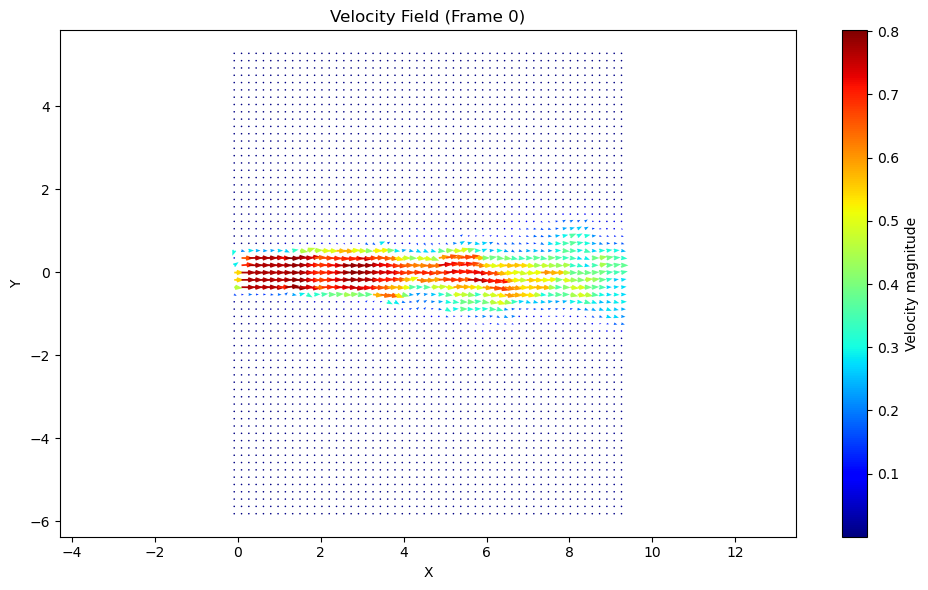

In [30]:
with h5py.File(mat_path, 'r') as f:
    X = f['X'][:]
    Y = f['Y'][:]
    U = f['U'][0]  # First frame
    V = f['V'][0]

# === Subsample for clarity ===
step = 5  # Adjust to control density of arrows
Xq = X[::step, ::step]
Yq = Y[::step, ::step]
Uq = U[::step, ::step]
Vq = V[::step, ::step]

# Calculate velocity magnitude for coloring
speed = np.sqrt(Uq**2 + Vq**2)

# === Plot ===
plt.figure(figsize=(10, 6))
q = plt.quiver(Xq, Yq, Uq, Vq, speed, scale=40, cmap='jet', headwidth=3, headlength=4)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Velocity Field (Frame 0)')
plt.axis('equal')
plt.colorbar(q, label='Velocity magnitude')
plt.tight_layout()
plt.show()

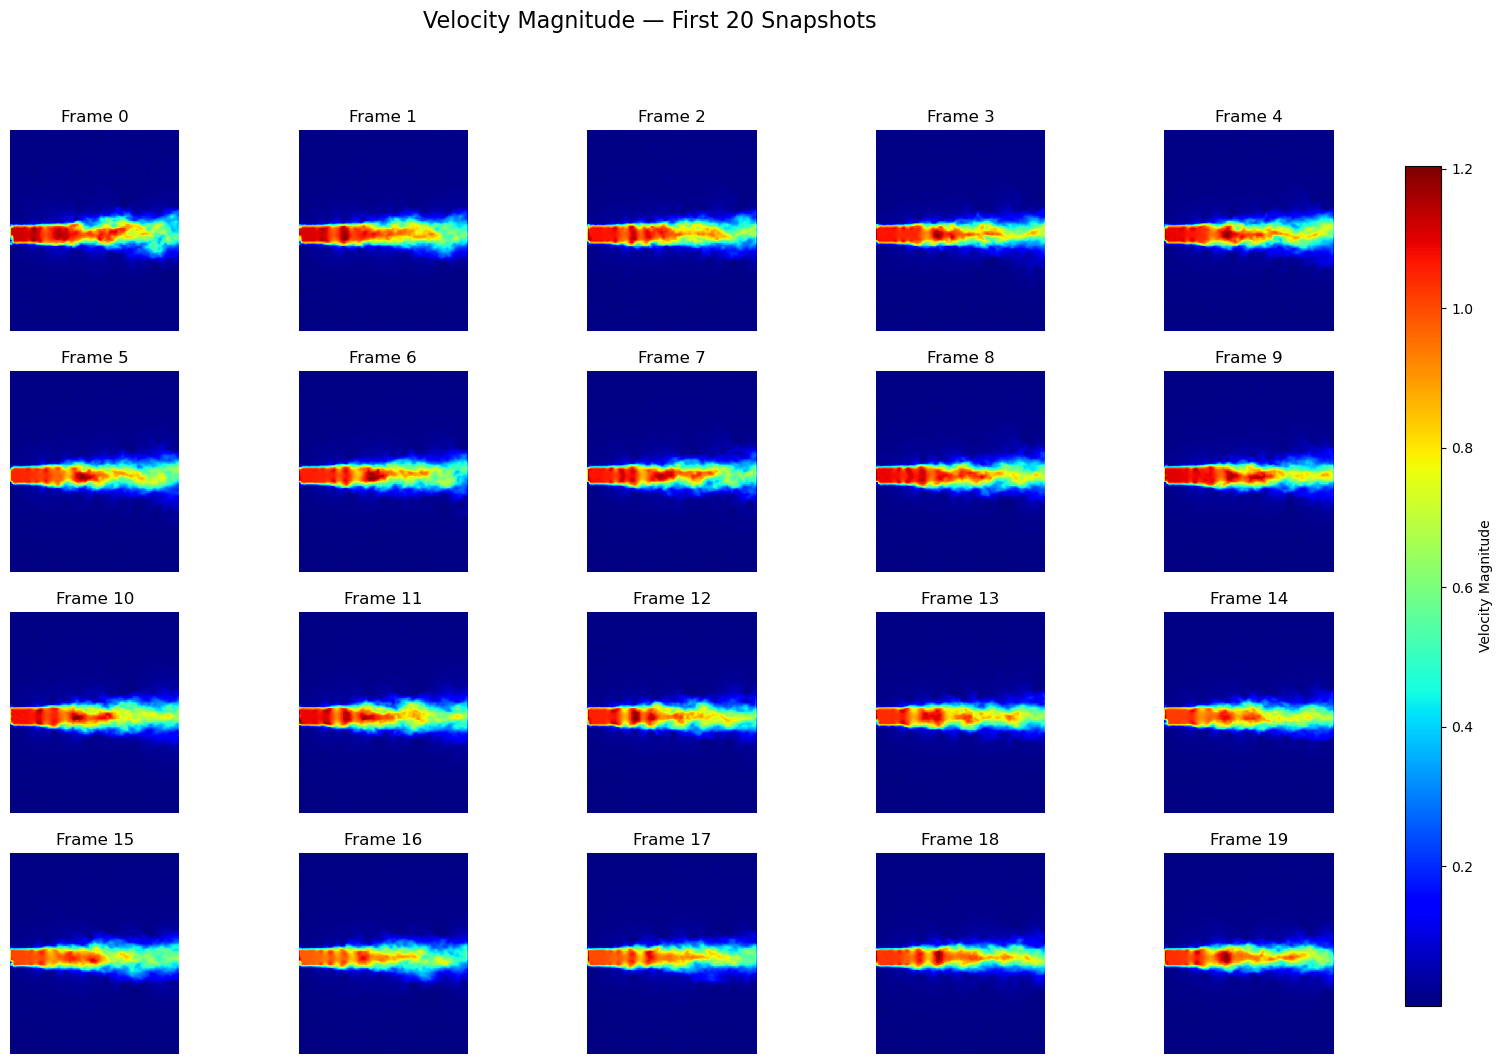

In [15]:
with h5py.File(mat_path, 'r') as f:
    X = f['X'][:]
    Y = f['Y'][:]
    U_all = f['U'][:20]  # First 20 time snapshots
    V_all = f['V'][:20]

# === Plot ===
fig, axes = plt.subplots(4, 5, figsize=(18, 12))
fig.suptitle('Velocity Magnitude — First 20 Snapshots', fontsize=16)

for i in range(20):
    ax = axes[i // 5, i % 5]
    velocity_mag = np.sqrt(U_all[i]**2 + V_all[i]**2)
    pc = ax.pcolormesh(X, Y, velocity_mag, shading='auto', cmap='jet')
    ax.set_title(f'Frame {i}')
    ax.axis('off')  # Hide axes
    ax.set_aspect('equal')
    ax.invert_yaxis()

# Add a shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(pc, cax=cbar_ax, label='Velocity Magnitude')

plt.show()

## Jet Flow Analysis

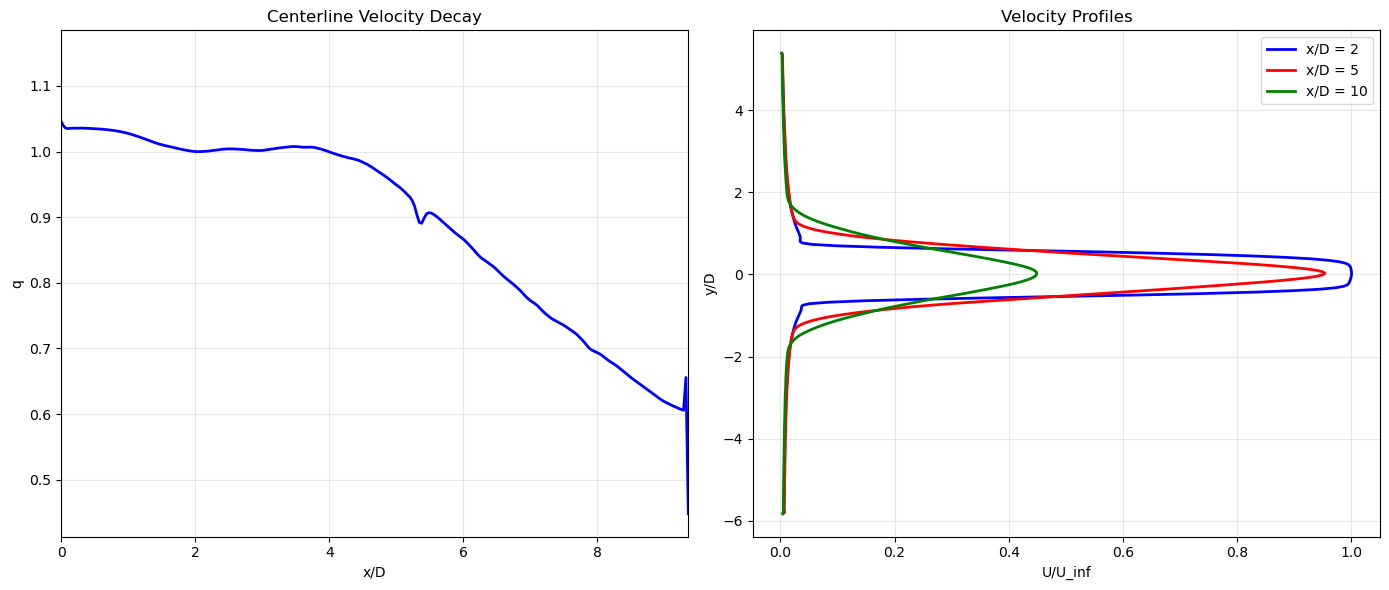

In [16]:
def plot_centerline_and_profiles(data, info):
    q = np.sqrt(data['Um']**2 + data['Vm']**2)
    X, Y = data['X'], data['Y']
    centerline_idx = info['centerline_idx']
    
    # Extract centerline data (assuming centerline is horizontal through the middle)
    centerline_q = q[:, centerline_idx]
    centerline_x = X[:, centerline_idx]

    # === Plot side-by-side ===
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # --- 1. Centerline velocity decay ---
    ax1.plot(centerline_x, centerline_q, 'b-', linewidth=2)
    ax1.set_xlabel('x/D')
    ax1.set_ylabel('q')
    ax1.set_title('Centerline Velocity Decay')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, centerline_x.max())

    # --- 2. Velocity profiles at selected x/D positions ---
    x_locations = [2, 5, 10]
    colors = ['blue', 'red', 'green']

    for x_loc, color in zip(x_locations, colors):
        # Find closest column to target x/D
        x_idx = np.abs(centerline_x - x_loc).argmin()
        velocity_profile = q[x_idx, :]
        y_profile = Y[x_idx, :]
        ax2.plot(velocity_profile, y_profile, color=color, linewidth=2, label=f'x/D = {x_loc}')

    ax2.set_xlabel('U/U_inf')
    ax2.set_ylabel('y/D')
    ax2.set_title('Velocity Profiles')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_centerline_and_profiles(data, info)

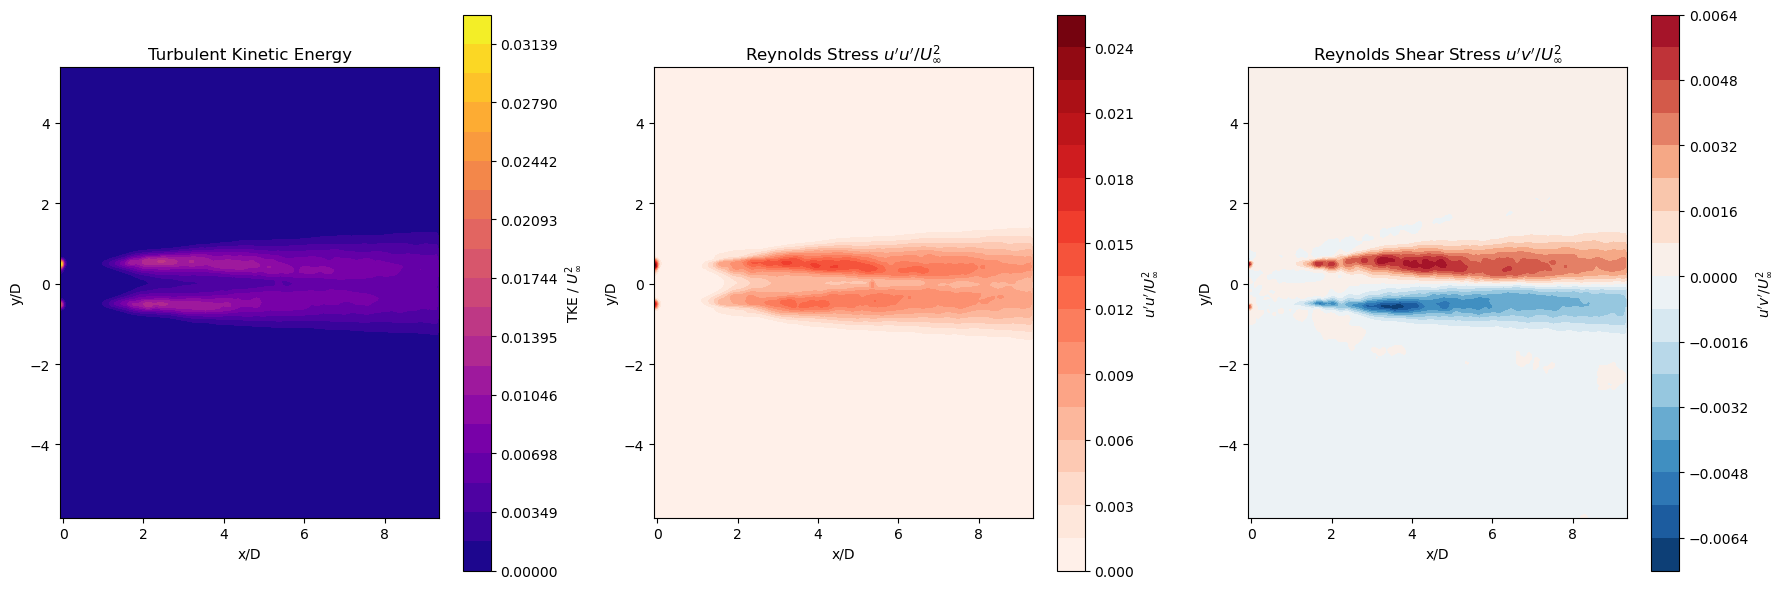

In [17]:
def plot_tke_and_stress(data):
    # === Plot side-by-side ===
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    # 4. Turbulent kinetic energy
    tke_levels = np.linspace(0, np.max(data['tke']), 20)
    im1 = ax1.contourf(data['X'], data['Y'], data['tke'], levels=tke_levels, cmap='plasma')
    ax1.set_title('Turbulent Kinetic Energy')
    ax1.set_xlabel('x/D'); ax1.set_ylabel('y/D')
    ax1.set_aspect('equal')
    fig.colorbar(im1, ax=ax1, label='TKE / $U_\infty^2$')

    # 5. Reynolds stress u'u'
    im2 = ax2.contourf(data['X'], data['Y'], data['u2'], levels=20, cmap='Reds')
    ax2.set_title(r"Reynolds Stress $u'u'/U_\infty^2$")
    ax2.set_xlabel('x/D'); ax2.set_ylabel('y/D')
    ax2.set_aspect('equal')
    fig.colorbar(im2, ax=ax2, label=r"$u'u'/U_\infty^2$")

    # 6. Reynolds shear stress u'v'
    uv_max = np.max(np.abs(data['uv']))
    im3 = ax3.contourf(data['X'], data['Y'], data['uv'], levels=20, cmap='RdBu_r', 
                       vmin=-uv_max, vmax=uv_max)
    ax3.set_title(r"Reynolds Shear Stress $u'v'/U_\infty^2$")
    ax3.set_xlabel('x/D'); ax3.set_ylabel('y/D')
    ax3.set_aspect('equal')
    fig.colorbar(im3, ax=ax3, label=r"$u'v'/U_\infty^2$")

    plt.tight_layout()
    plt.show()

plot_tke_and_stress(data)

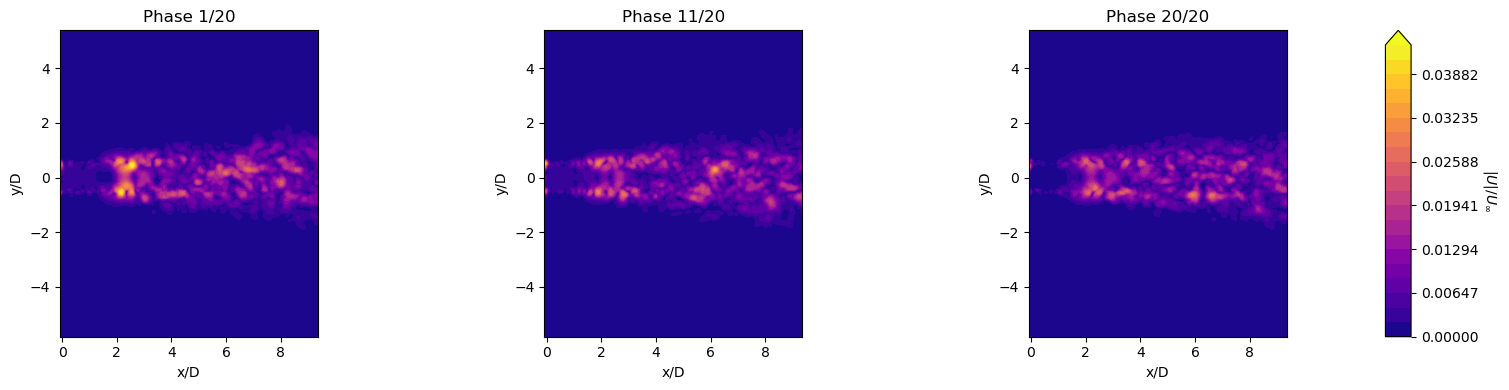

In [18]:
def plot_phase_averaged_magnitude(data, phases=[0, 10, 19]):
    X, Y, Uph, Vph = data['X'], data['Y'], data['Uph'], data['Vph']
    max_mag = max(np.sqrt(Uph[i]**2 + Vph[i]**2).max() for i in phases)
    levels = np.linspace(0, max_mag, 21)

    fig = plt.figure(figsize=(5 * len(phases) + 1, 4))
    gs = matplotlib.gridspec.GridSpec(1, len(phases) + 1, width_ratios=[1]*len(phases) + [0.05])
    
    for j, i in enumerate(phases):
        ax = fig.add_subplot(gs[0, j])
        mag = np.sqrt(Uph[i]**2 + Vph[i]**2)
        im = ax.contourf(X, Y, mag, levels=levels, cmap='plasma', extend='max')
        ax.set(title=f'Phase {i+1}/20', xlabel='x/D', ylabel='y/D', aspect='equal')

    # Colorbar on the last narrow column
    cax = fig.add_subplot(gs[0, -1])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$|U|/U_\infty$', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

plot_phase_averaged_magnitude(data)

## Phase and POD plots

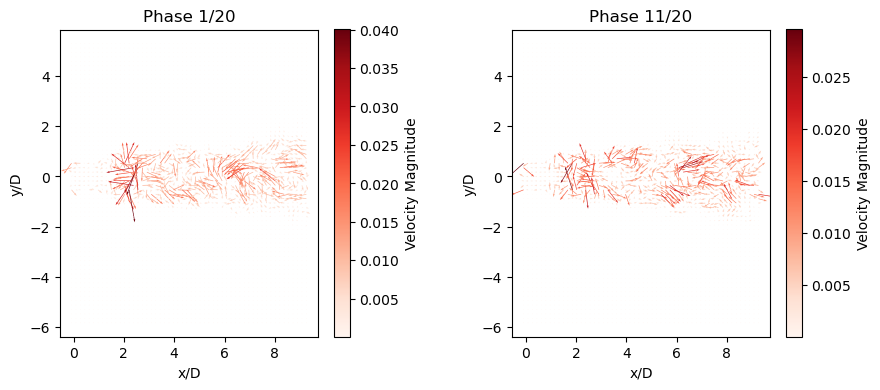

In [19]:
def plot_phase_averaged_quiver(data, phases=[0, 10], step=5):
    X, Y, Uph, Vph = data['X'], data['Y'], data['Uph'], data['Vph']

    fig = plt.figure(figsize=(5 * len(phases), 4))
    gs = matplotlib.gridspec.GridSpec(1, len(phases), wspace=0.4)

    for j, i in enumerate(phases):
        ax = fig.add_subplot(gs[0, j])
        U = Uph[i][::step, ::step]
        V = Vph[i][::step, ::step]
        speed = np.sqrt(U**2 + V**2)
        quiver = ax.quiver(X[::step, ::step], Y[::step, ::step], U, V, speed, cmap = 'Reds',
                  angles='xy', scale_units='xy', scale=0.03, width=0.0025)
        cb = fig.colorbar(quiver, ax=ax)
        cb.set_label('Velocity Magnitude')
        ax.set_title(f'Phase {i+1}/20')
        ax.set_xlabel('x/D')
        ax.set_ylabel('y/D')
        ax.set_aspect('equal')

    plt.subplots_adjust(wspace=0.4)
    plt.show()

plot_phase_averaged_quiver(data)

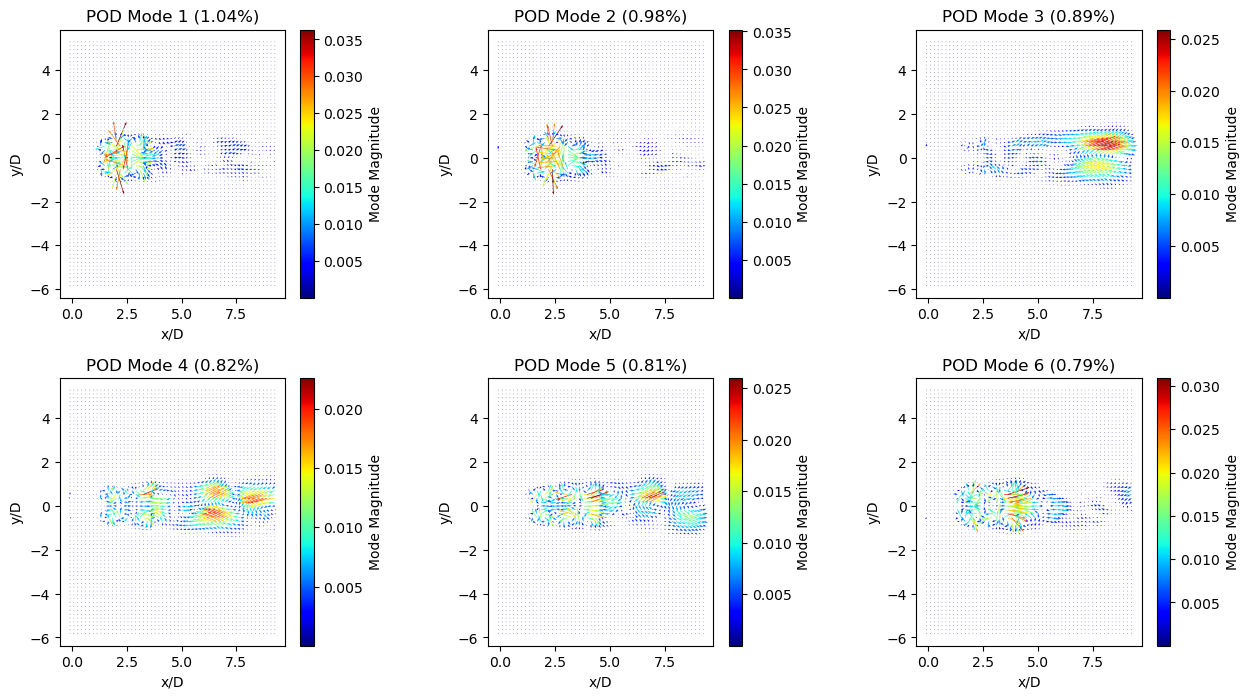

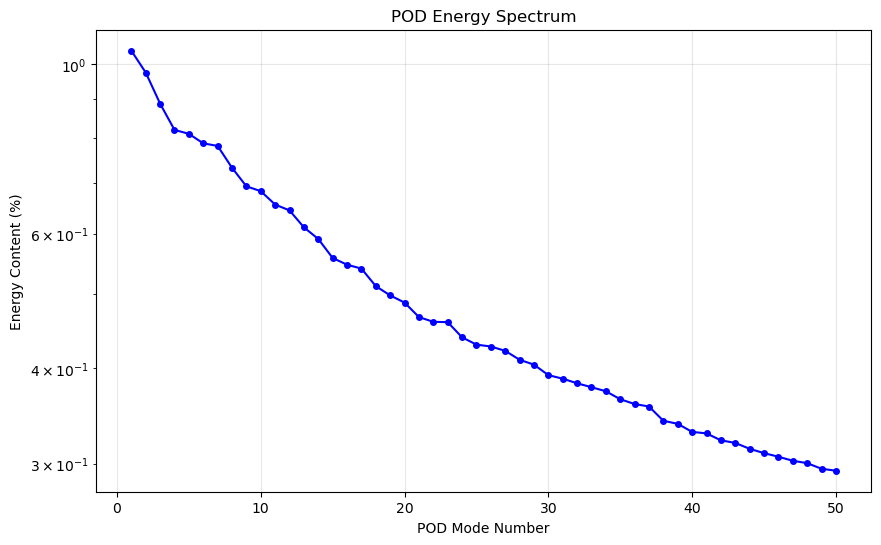

In [20]:
def analyze_pod_modes(data, n_modes=6, step=5):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    X, Y = data['X'], data['Y']
    ny, nx = X.shape
    
    # Energy content
    total_energy = np.sum(data['Sig'][0, :])

    # Plot first 6 modes
    for i in range(n_modes):
        if i >= data['Phi'].shape[0]:  # Check number of modes (rows)
            break
            
        row, col = i // 3, i % 3
        
        # Get mode data - modes are rows, spatial points are columns
        mode_data = data['Phi'][i, :]  # Get i-th mode (row)
        
        # Handle stacked U,V components
        u_mode = mode_data[:ny*nx].reshape(ny, nx)
        v_mode = mode_data[ny*nx:].reshape(ny, nx)
        
        # Subsample for quiver plot
        u_quiv = u_mode[::step, ::step]
        v_quiv = v_mode[::step, ::step]
        
        # Calculate magnitude for color coding
        magnitude = np.sqrt(u_quiv**2 + v_quiv**2)
        
        # Create quiver plot
        quiver = axes[row, col].quiver(X[::step, ::step], Y[::step, ::step], 
                                       u_quiv, v_quiv, magnitude, 
                                       cmap='jet', angles='xy', scale_units='xy', 
                                       scale=0.03, width=0.003)
        
        axes[row, col].set_title(f'POD Mode {i+1} ({data["Sig"][0,i]/total_energy*100:.2f}%)')
        axes[row, col].set_xlabel('x/D')
        axes[row, col].set_ylabel('y/D')
        axes[row, col].set_aspect('equal')
        
        # Add colorbar for magnitude
        cb = plt.colorbar(quiver, ax=axes[row, col])
        cb.set_label('Mode Magnitude')
    
    plt.subplots_adjust(hspace=0.3, wspace=0.4)
    plt.show()
    
    # Plot energy spectrum
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    modes = np.arange(1, min(51, len(data['Sig'][0])+1))
    energy_percent = data['Sig'][0, :len(modes)] / total_energy * 100
    
    ax.semilogy(modes, energy_percent, 'bo-', markersize=4)
    ax.set_xlabel('POD Mode Number')
    ax.set_ylabel('Energy Content (%)')
    ax.set_title('POD Energy Spectrum')
    ax.grid(True, alpha=0.3)
    plt.show()


analyze_pod_modes(data)

## Temporal Analysis

We will analyze the spectral information at a random point to see if the data has any periodicity or is locked to an actuator (this is just to make sure the variables U and V are time-resolved and SPOD can be applied)

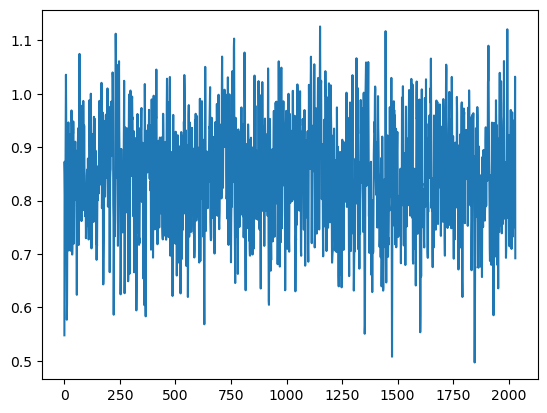

In [21]:
u_center = data['U'][:, 134, 159]
plt.plot(u_center)

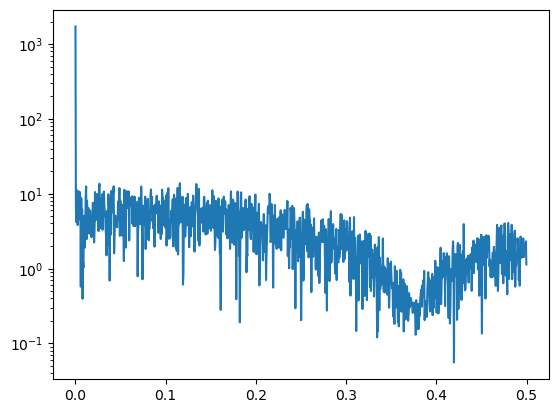

In [22]:
fft_vals = np.fft.rfft(u_center)
freqs = np.fft.rfftfreq(len(u_center), 1)  # assuming dt=1

plt.semilogy(freqs, np.abs(fft_vals))

## Flow Field Animation

In [48]:
def animate_quiver(data, skip=5, interval=200, scale=40, frames_to_plot=20):
    X, Y = data['X'], data['Y']
    U_all, V_all = data['U'], data['V']  # Shape: (nt, ny, nx)
    
    # Downsample for quiver clarity
    Xq, Yq = X[::skip, ::skip], Y[::skip, ::skip]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_title("Instantaneous Flow Field")
    ax.set_xlabel("x/D")
    ax.set_ylabel("y/D")
    ax.set_aspect("equal")
    ax.set_xlim(X.min(), X.max())
    ax.set_ylim(Y.min(), Y.max())

    # First frame data
    U0 = U_all[0][::skip, ::skip]
    V0 = V_all[0][::skip, ::skip]
    mag0 = np.sqrt(U0**2 + V0**2)

    # Initialize quiver with color by magnitude
    quiv = ax.quiver(Xq, Yq, U0, V0, mag0, cmap='jet', scale=scale, width=0.0025)
    cbar = plt.colorbar(quiv, ax=ax, label='|U|/U∞')

    def update(frame):
        U = U_all[frame][::skip, ::skip]
        V = V_all[frame][::skip, ::skip]
        mag = np.sqrt(U**2 + V**2)
        quiv.set_UVC(U, V, mag)
        ax.set_title(f"Phase {frame+1}/{len(U_all)}")
        return quiv,


    ani = animation.FuncAnimation(fig, update, frames=np.arange(frames_to_plot), interval=interval, blit=False)
    plt.close(fig)  # Prevent static display in Jupyter
    return HTML(ani.to_jshtml())

In [51]:
display(animate_quiver(data, skip=10, scale=20, frames_to_plot=20))

This animation does not give much insight at the moment. We will apply SPOD so as to analyze the flow field in terms of frequencies and modes, which will make it easier to extract conclusions and useful information.

# SPOD

In [25]:
# Save to compressed NumPy format
np.savez_compressed("RUN1_PIV_compressed.npz", X=data['X'], Y=data['Y'], U=data['U'], V=data['V'])

This is the data used to compute SPOD. I have computed SPOD in Google Colab to make use of cloud resources and the gpus provided by google. The code corresponding to SPOD is included in another notebook.

In [7]:
def save_piv_runs(min_run,
                  max_run,
                  mat_pattern="data/Run{}_PIV.mat",
                  out_dir="compressed_data",
                  vars_to_save=("X", "Y", "u", "v"),
                  loader=None,
                  overwrite=False):
    """
    Load PIV .mat files using your notebook loader and save X,Y,u,v
    as compressed .npz files.

    Parameters
    ----------
    min_run : int
        First run number to process (1..25).
    max_run : int
        Last run number to process (1..25).
    mat_pattern : str
        Path pattern for the .mat files. Should contain one {} for the run number,
        e.g. "data/Run{}_PIV.mat" (matches your notebook).
    out_dir : str
        Directory where compressed .npz files will be saved.
    vars_to_save : tuple
        Names of variables to save from the loader's returned dict.
    loader : callable or None
        Function to load one mat file. If None, uses `load_piv_data` from the notebook.
        Signature must be: loader(mat_path) -> dict-like with requested keys.
    overwrite : bool
        If True, overwrite existing compressed files.

    Returns
    -------
    saved_files : list
        List of saved file paths.
    """
    # clamp and validation
    if min_run < 1 or max_run < 1:
        raise ValueError("min_run and max_run must be >= 1")
    if min_run > max_run:
        raise ValueError("min_run cannot be greater than max_run")
    min_run = max(1, min_run)
    max_run = min(25, max_run)

    # use notebook loader by default
    if loader is None:
        try:
            loader = load_piv_data
        except NameError:
            raise NameError("loader not provided and `load_piv_data` not found in the notebook namespace.")

    os.makedirs(out_dir, exist_ok=True)
    saved_files = []

    for i in range(min_run, max_run + 1):
        mat_path = mat_pattern.format(i)
        out_name = os.path.join(out_dir, f"RUN{i}_PIV_compressed.npz")

        if os.path.exists(out_name) and not overwrite:
            print(f"[skip] {out_name} (exists). Use overwrite=True to replace.")
            saved_files.append(out_name)
            continue

        try:
            data = loader(mat_path)
        except Exception as e:
            print(f"[error] Could not load '{mat_path}': {e}")
            continue

        missing = [k for k in vars_to_save if k not in data]
        if missing:
            print(f"[skip] '{mat_path}' missing keys: {missing}")
            continue

        # Save requested variables
        try:
            np.savez_compressed(out_name, **{k: data[k] for k in vars_to_save})
            print(f"[saved] {out_name} (vars: {', '.join(vars_to_save)})")
            saved_files.append(out_name)
        except Exception as e:
            print(f"[error] Failed saving '{out_name}': {e}")

    return saved_files


In [8]:
saved = save_piv_runs(1, 25)

[saved] compressed_data\RUN1_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN2_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN3_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN4_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN5_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN6_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN7_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN8_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN9_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN10_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN11_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN12_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN13_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN14_PIV_compressed.npz (vars: X, Y, u, v)
[saved] compressed_data\RUN15_PIV_compressed.npz (vars: X